<a href="https://colab.research.google.com/github/nicolastibata/MINE_4210_ADL_202620/blob/main/assingments/assingment_1/MINE_4210_ADL_202620_T1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo ADL](https://github.com/nicolastibata/MINE_4210_ADL_202620/blob/main/docs/logo.png?raw=true)


# **Taller 1: Clasificación multiclase con un MLP**

### **Contexto y Objetivos**

La obesidad es un problema de salud pública creciente, asociado a enfermedades cardiovasculares, diabetes y otras condiciones crónicas. Identificar el nivel de riesgo de una persona a partir de sus hábitos, sin depender de mediciones clínicas directas como el peso o la estatura, puede ser útil cuando esta información no está disponible o se busca anticipar el riesgo antes de que se manifieste físicamente. En este taller deberán estimar el nivel de obesidad de una persona a partir de variables sociodemográficas y de estilo de vida, como alimentación, actividad física, consumo de alcohol y medio de transporte.

El objetivo de este Taller es construir un perceptrón multicapa (MLP) para esta tarea, siguiendo el proceso de machine learning. Se realizará una búsqueda de hiperparámetros sobre la arquitectura de la red, variando el número de capas ocultas y el número de neuronas por capa.


| Hiperparámetro | Valores para explorar |
|-|-|
| Número de capas ocultas | 1, 2 o 3. |
| Neuronas por capa oculta | 16, 32 o 64 (mismo valor en todas las capas ocultas de una misma arquitectura). |
| Callback obligatorio | Early stopping, monitoreando val_loss, con un valor de patience justificado. |


### **Entregable**

Notebook (.ipynb) con todas las celdas ejecutadas y con todas las indicaciones anteriormente estipuladas en la sección de laboratorios en **Bloque Neón**.



### **Rúbrica**

| Criterio | Peso | Qué se evalúa |
|-|-|-|
| Preprocesamiento de datos | 15 % | Codificación adecuada de las variables categóricas, diferenciando entre nominales y ordinales escalamiento de las variables numéricas; y separación correcta de los conjuntos de entrenamiento, <br> validación y prueba, evitando fuga de información. |
| Implementación del MLP | 15 % | Arquitectura correctamente construida, con función de activación de salida y función de pérdida apropiadas para clasificación multiclase; código funcional y bien organizado. |
| Búsqueda de hiperparámetros | 25 % | Las 9 configuraciones están correctamente implementadas y entrenadas, early stopping está configurado con un valor de patience justificado. Los resultados se presentan de forma <br> clara mediante una tabla o gráfico comparativo. |
| Evaluación y métricas | 15 % | Uso de métricas apropiadas para clasificación multiclase, considerando posibles diferencias en el tamaño de las clases; evaluación final realizada correctamente sobre el conjunto de test.  |
| Interpretación y justificación | 20 % | Justificación de la arquitectura final con base en los resultados y las curvas de entrenamiento y validación; identificación de señales de sobreajuste o subajuste; conclusiones sobre el efecto <br> de la profundidad y el ancho de la red. |
| Calidad y reproducibilidad del notebook | 10 % | El notebook se ejecuta de principio a fin sin errores, está organizado en un orden lógico, no contiene código innecesario e incluye explicaciones breves en Markdown que guían la lectura. |

# PREPROCESAMIENTO DE DATOS

In [1]:
import pandas as pd
import numpy as np

In [2]:
ruta = 'obesidad.csv'
df_obesidad=pd.read_csv(ruta, sep=";")

In [3]:
df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,Actividad_fisica,Tiempo_pantallas,Alcohol,Transporte,Nivel_obesidad
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,0,1,No,Transporte_Publico,Peso_Normal
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,3,0,A veces,Transporte_Publico,Peso_Normal
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,2,1,Frecuentemente,Transporte_Publico,Peso_Normal
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,2,0,Frecuentemente,Caminando,Sobrepeso_Nivel_I
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,0,0,A veces,Transporte_Publico,Sobrepeso_Nivel_II


In [4]:
df_obesidad.describe()

,Edad,Frecuencia_verduras,Comidas_dia,Agua_dia,Actividad_fisica,Tiempo_pantallas
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000
mean,24.353090,2.425970,2.703402,2.011500,1.009104,0.669861
std,6.368801,0.585177,0.797108,0.685322,0.898712,0.673970
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.915937,2.000000,3.000000,2.000000,0.000000,0.000000
50%,22.847618,2.000000,3.000000,2.000000,1.000000,1.000000
75%,26.000000,3.000000,3.000000,2.000000,2.000000,1.000000
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [5]:
df_obesidad["Agua_dia"].value_counts(normalize=True)

Agua_dia
2    0.530426
3    0.240537
1    0.229037
Name: proportion, dtype: float64

### Codificación de variables nominales: `Alcohol` y `Transporte`

`Transporte` es una variable nominal: sus categorías (Automovil, Motocicleta, Bicicleta, Caminando, Transporte_Publico) no tienen un orden natural.

`Alcohol` (No, A veces, Frecuentemente, Siempre) sí sugiere un orden de frecuencia, pero en este taller se trata como **nominal** por el espaciado desigual e incierto entre sus categorías. Ambas se codifican con **one-hot encoding**.

In [6]:
variables_nominales = ["Alcohol", "Transporte"]

df_obesidad = pd.get_dummies(df_obesidad, columns=variables_nominales, dtype=int)

df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,...,Nivel_obesidad,Alcohol_A veces,Alcohol_Frecuentemente,Alcohol_No,Alcohol_Siempre,Transporte_Automovil,Transporte_Bicicleta,Transporte_Caminando,Transporte_Motocicleta,Transporte_Transporte_Publico
0,Femenino,21.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,0,1,0,0,0,0,0,1
1,Femenino,21.0,Si,No,3,3,A veces,Si,3,Si,...,Peso_Normal,1,0,0,0,0,0,0,0,1
2,Masculino,23.0,Si,No,2,3,A veces,No,2,No,...,Peso_Normal,0,1,0,0,0,0,0,0,1
3,Masculino,27.0,No,No,3,3,A veces,No,2,No,...,Sobrepeso_Nivel_I,0,1,0,0,0,0,1,0,0
4,Masculino,22.0,No,No,2,1,A veces,No,2,No,...,Sobrepeso_Nivel_II,1,0,0,0,0,0,0,0,1


### Codificación de variables binarias

`Antecedentes_familiares`, `Come_calorico`, `Fuma`, `Monitorea_calorias` y `Genero` tienen exactamente dos categorías, así que se codifican como una sola columna 0/1 en lugar de one-hot completo (evita una columna redundante, sin introducir ninguna relación de orden porque con 2 categorías no existe ambigüedad de orden).

In [7]:
mapeo_si_no = {"No": 0, "Si": 1}
variables_binarias_si_no = ["Antecedentes_familiares", "Come_calorico", "Fuma", "Monitorea_calorias"]

for col in variables_binarias_si_no:
    df_obesidad[col] = df_obesidad[col].map(mapeo_si_no)

df_obesidad["Genero"] = df_obesidad["Genero"].map({"Femenino": 0, "Masculino": 1})

df_obesidad[variables_binarias_si_no + ["Genero"]].head()

,Antecedentes_familiares,Come_calorico,Fuma,Monitorea_calorias,Genero
0,1,0,0,0,0
1,1,0,1,1,0
2,1,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1


### Codificación de variables ordinales: `Picoteo` y `Agua_dia`

`Picoteo` (No < A veces < Frecuentemente < Siempre) tiene un orden claro de frecuencia, así que se mapea a enteros consecutivos respetando ese orden (no se puede usar el orden alfabético porque no coincide con el orden real).

`Agua_dia` ya viene codificada como entero (1, 2, 3) representando categorías crecientes de consumo de agua, así que no requiere transformación adicional.

In [8]:
mapeo_picoteo = {"No": 0, "A veces": 1, "Frecuentemente": 2, "Siempre": 3}
df_obesidad["Picoteo"] = df_obesidad["Picoteo"].map(mapeo_picoteo)

df_obesidad[["Picoteo", "Agua_dia"]].head()

,Picoteo,Agua_dia
0,1,2
1,1,3
2,1,2
3,1,2
4,1,2


In [9]:
df_obesidad.head()

,Genero,Edad,Antecedentes_familiares,Come_calorico,Frecuencia_verduras,Comidas_dia,Picoteo,Fuma,Agua_dia,Monitorea_calorias,...,Nivel_obesidad,Alcohol_A veces,Alcohol_Frecuentemente,Alcohol_No,Alcohol_Siempre,Transporte_Automovil,Transporte_Bicicleta,Transporte_Caminando,Transporte_Motocicleta,Transporte_Transporte_Publico
0,0,21.0,1,0,2,3,1,0,2,0,...,Peso_Normal,0,0,1,0,0,0,0,0,1
1,0,21.0,1,0,3,3,1,1,3,1,...,Peso_Normal,1,0,0,0,0,0,0,0,1
2,1,23.0,1,0,2,3,1,0,2,0,...,Peso_Normal,0,1,0,0,0,0,0,0,1
3,1,27.0,0,0,3,3,1,0,2,0,...,Sobrepeso_Nivel_I,0,1,0,0,0,0,1,0,0
4,1,22.0,0,0,2,1,1,0,2,0,...,Sobrepeso_Nivel_II,1,0,0,0,0,0,0,0,1


## SEPARACIÓN EN TRAIN / VALIDATION / TEST

Separamos el dataset en tres conjuntos **antes** de escalar las variables numéricas, para evitar fuga de información (el escalador se debe ajustar únicamente con el conjunto de entrenamiento):

- **Entrenamiento (70%)**: se usa para ajustar los pesos de la red.
- **Validación (15%)**: se usa para comparar las 9 configuraciones de hiperparámetros (número de capas, neuronas por capa, optimizador, activación de salida, etc.) y para el early stopping, sin tocar el conjunto de prueba.
- **Prueba (15%)**: se usa **una sola vez**, al final, sobre el modelo ya elegido, para estimar qué tan bien generaliza.

Usamos `train_test_split` de scikit-learn dos veces (primero separamos test, luego dividimos el resto en train/val), con `stratify` sobre `Nivel_obesidad` para que las proporciones de cada clase se mantengan en los tres conjuntos, dado que hay leves diferencias en el tamaño de las clases.

In [10]:
from sklearn.model_selection import train_test_split

X = df_obesidad.drop(columns=["Nivel_obesidad"])
y = df_obesidad["Nivel_obesidad"]

# Primero separamos el conjunto de prueba (15% del total)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

# Del 85% restante, separamos validación (15% del total => 15/85 del restante) y entrenamiento (70% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15 / 0.85, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0] / len(X):.1%})")
print(f"Val:   {X_val.shape[0]} filas ({X_val.shape[0] / len(X):.1%})")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0] / len(X):.1%})")

Train: 1460 filas (70.0%)
Val:   313 filas (15.0%)
Test:  314 filas (15.0%)


In [11]:
# Verificamos que la estratificación preservó las proporciones de clase en los 3 conjuntos
pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Val": y_val.value_counts(normalize=True),
    "Test": y_test.value_counts(normalize=True),
})

,Train,Val,Test
Nivel_obesidad,,,
Obesidad_Tipo_I,0.167808,0.169329,0.168790
Obesidad_Tipo_III,0.154795,0.156550,0.156051
Obesidad_Tipo_II,0.141781,0.143770,0.143312
Sobrepeso_Nivel_II,0.139041,0.137380,0.140127
Peso_Normal,0.135616,0.134185,0.133758
Sobrepeso_Nivel_I,0.132877,0.130990,0.130573
Peso_Insuficiente,0.128082,0.127796,0.127389


## ESCALAMIENTO DE VARIABLES NUMÉRICAS

Estandarizamos (media 0, varianza 1) `Edad` junto con las variables ordinales numéricas (`Frecuencia_verduras`, `Comidas_dia`, `Agua_dia`, `Actividad_fisica`, `Tiempo_pantallas`, `Picoteo`), para que ninguna domine el entrenamiento solo por tener una escala más grande. Las binarias y las one-hot (`Alcohol_*`, `Transporte_*`) se dejan como están (0/1).

El `StandardScaler` se **ajusta únicamente con `X_train`** y luego se aplica (transform, no fit) sobre `X_val` y `X_test`, para no filtrar información de validación/prueba hacia el preprocesamiento.

In [12]:
from sklearn.preprocessing import StandardScaler

variables_numericas = [
    "Edad", "Frecuencia_verduras", "Comidas_dia",
    "Agua_dia", "Actividad_fisica", "Tiempo_pantallas", "Picoteo",
]

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

scaler = StandardScaler()
X_train[variables_numericas] = scaler.fit_transform(X_train[variables_numericas])
X_val[variables_numericas] = scaler.transform(X_val[variables_numericas])
X_test[variables_numericas] = scaler.transform(X_test[variables_numericas])

X_train[variables_numericas].describe()

,Edad,Frecuencia_verduras,Comidas_dia,Agua_dia,Actividad_fisica,Tiempo_pantallas,Picoteo
count,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03
mean,9.368457e-17,-6.205082e-17,-2.871371e-16,-7.665101e-17,2.676702e-17,4.623395e-17,2.433366e-18
std,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00,1.000343e+00
min,-1.458845e+00,-2.445740e+00,-2.187204e+00,-1.432652e+00,-1.117123e+00,-9.930352e-01,-2.503294e+00
25%,-7.038946e-01,-7.323137e-01,3.582866e-01,1.587427e-02,-1.117123e+00,-9.930352e-01,-3.187098e-01
50%,-2.422895e-01,-7.323137e-01,3.582866e-01,1.587427e-02,2.184319e-02,4.818696e-01,-3.187098e-01
75%,2.495748e-01,9.811125e-01,3.582866e-01,1.587427e-02,1.160809e+00,4.818696e-01,-3.187098e-01
max,5.685456e+00,9.811125e-01,1.631032e+00,1.464401e+00,2.299775e+00,1.956774e+00,4.050458e+00


# Implementación del MLP

In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

label_encoder.classes_

array(['Obesidad_Tipo_I', 'Obesidad_Tipo_II', 'Obesidad_Tipo_III',
       'Peso_Insuficiente', 'Peso_Normal', 'Sobrepeso_Nivel_I',
       'Sobrepeso_Nivel_II'], dtype=object)

### Función de activación de salida y función de pérdida

`Nivel_obesidad` es un problema de clasificación **multiclase de una sola etiqueta** (cada persona pertenece a exactamente una de las 7 categorías, no a varias a la vez). Por eso:

- **Softmax** en la capa de salida: convierte los logits en una distribución de probabilidad sobre las 7 clases (todas positivas y suman 1), a diferencia de sigmoid, que trataría cada clase como independiente (apropiado para multi-etiqueta, no aquí).
- **Entropía cruzada** como función de pérdida: es la función de costo estándar para clasificación con salida softmax. Usamos `sparse_categorical_crossentropy` porque codificamos el target como enteros (0-6) con `LabelEncoder` en vez de one-hot — es matemáticamente equivalente a `categorical_crossentropy` con targets one-hot, pero evita el paso extra de `to_categorical`.

La arquitectura se define con una función `build_model` para poder instanciar fácilmente las 9 combinaciones de (número de capas ocultas, neuronas por capa) en la búsqueda de hiperparámetros.

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_model(n_hidden_layers, n_neurons, input_dim, n_classes):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for _ in range(n_hidden_layers):
        model.add(layers.Dense(n_neurons, activation="relu"))

    model.add(layers.Dense(n_classes, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

I0000 00:00:1788541877.787250  222765 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788541877.885801  222765 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788541880.686754  222765 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [15]:
# Ejemplo de instanciación (una de las 9 combinaciones que se probarán en la búsqueda de hiperparámetros)
n_features = X_train.shape[1]
n_classes = len(label_encoder.classes_)

modelo_ejemplo = build_model(n_hidden_layers=2, n_neurons=32, input_dim=n_features, n_classes=n_classes)
modelo_ejemplo.summary()

I0000 00:00:1788541882.264747  222765 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2909 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,991 (7.78 KB)

 Trainable params: 1,991 (7.78 KB)

 Non-trainable params: 0 (0.00 B)

# Búsqueda de hiperparámetros

Probamos las 9 combinaciones de (número de capas ocultas ∈ {1,2,3}) × (neuronas por capa ∈ {16,32,64}), reutilizando `build_model`. Cada modelo se entrena con un `EarlyStopping` propio que monitorea `val_loss`, con **`patience=15`** y `restore_best_weights=True`.

¿Por qué `patience=15`? El conjunto de validación es pequeño (313 filas), así que `val_loss` fluctúa de época a época por ruido normal del entrenamiento; un valor bajo (2-3) arriesga parar antes de que el modelo realmente converja. Como los modelos son pequeños y entrenan rápido, el costo de esperar 15 épocas sin mejora es bajo, así que preferimos ese margen antes que arriesgar una parada prematura. Fijamos un tope de 150 épocas para que sea el early stopping —no el límite— el que decida cuándo parar.

Para cada combinación guardamos el mejor `val_loss`/`val_accuracy` (según la época que `restore_best_weights` recupera) y cuántas épocas tardó en converger.

In [16]:
import itertools
import time

n_capas_ocultas_opciones = [1, 2, 3]
n_neuronas_opciones = [16, 32, 64]

resultados = []
historias = {}

for n_capas, n_neuronas in itertools.product(n_capas_ocultas_opciones, n_neuronas_opciones):
    keras.utils.set_random_seed(42)

    modelo = build_model(
        n_hidden_layers=n_capas,
        n_neurons=n_neuronas,
        input_dim=n_features,
        n_classes=n_classes,
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
    )

    inicio = time.time()
    historia = modelo.fit(
        X_train, y_train_enc,
        validation_data=(X_val, y_val_enc),
        epochs=150,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=0,
    )
    duracion = time.time() - inicio

    mejor_epoca = int(np.argmin(historia.history["val_loss"]))
    historias[(n_capas, n_neuronas)] = historia.history

    resultados.append({
        "n_capas_ocultas": n_capas,
        "n_neuronas": n_neuronas,
        "val_loss": historia.history["val_loss"][mejor_epoca],
        "val_accuracy": historia.history["val_accuracy"][mejor_epoca],
        "epocas_entrenadas": len(historia.history["val_loss"]),
        "mejor_epoca": mejor_epoca + 1,
        "tiempo_seg": round(duracion, 1),
    })

    print(
        f"Capas={n_capas}, Neuronas={n_neuronas} -> "
        f"val_loss={resultados[-1]['val_loss']:.4f}, "
        f"val_accuracy={resultados[-1]['val_accuracy']:.4f}, "
        f"epocas={resultados[-1]['epocas_entrenadas']}"
    )

I0000 00:00:1788541885.258242  222879 service.cc:153] XLA service 0x7f4e50017140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788541885.258291  222879 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788541885.306163  222879 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1788541885.597508  222879 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788541885.606686  222879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1007__.12


I0000 00:00:1788541888.961383  222879 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


I0000 00:00:1788541889.376742  222879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1007__.12


Capas=1, Neuronas=16 -> val_loss=0.9676, val_accuracy=0.6773, epocas=150


...

I0000 00:00:1788542270.396127  222876 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_189702__.14


Capas=3, Neuronas=32 -> val_loss=0.9240, val_accuracy=0.6741, epocas=53


I0000 00:00:1788542300.650421  222875 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_205296__.14


I0000 00:00:1788542303.332515  222875 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_205296__.14


Capas=3, Neuronas=64 -> val_loss=0.7956, val_accuracy=0.7316, epocas=32


In [17]:
df_resultados = pd.DataFrame(resultados).sort_values("val_loss").reset_index(drop=True)
df_resultados

,n_capas_ocultas,n_neuronas,val_loss,val_accuracy,epocas_entrenadas,mejor_epoca,tiempo_seg
0,3,64,0.795578,0.731629,32,17,20.5
1,2,64,0.834646,0.725240,42,27,34.9
2,1,64,0.855039,0.741214,107,92,58.8
3,1,32,0.866086,0.686901,127,112,66.8
4,3,16,0.873312,0.706070,93,78,46.9
5,2,16,0.921040,0.686901,116,101,61.5
6,3,32,0.924027,0.674121,53,38,31.8
7,2,32,0.933200,0.674121,54,39,33.7
8,1,16,0.967583,0.677316,150,138,79.2


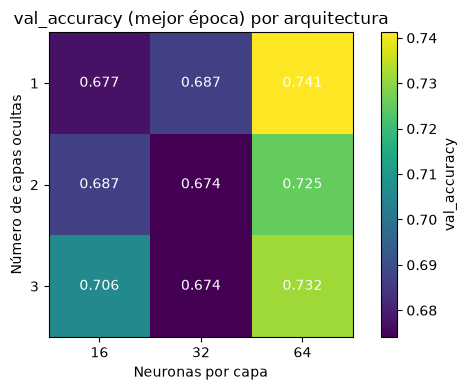

In [18]:
import matplotlib.pyplot as plt

pivot_accuracy = df_resultados.pivot(index="n_capas_ocultas", columns="n_neuronas", values="val_accuracy")

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot_accuracy.values, cmap="viridis")

ax.set_xticks(range(len(pivot_accuracy.columns)))
ax.set_xticklabels(pivot_accuracy.columns)
ax.set_yticks(range(len(pivot_accuracy.index)))
ax.set_yticklabels(pivot_accuracy.index)
ax.set_xlabel("Neuronas por capa")
ax.set_ylabel("Número de capas ocultas")
ax.set_title("val_accuracy (mejor época) por arquitectura")

for i in range(pivot_accuracy.shape[0]):
    for j in range(pivot_accuracy.shape[1]):
        ax.text(j, i, f"{pivot_accuracy.values[i, j]:.3f}", ha="center", va="center", color="white")

fig.colorbar(im, ax=ax, label="val_accuracy")
plt.tight_layout()
plt.show()

## Curvas de entrenamiento y validación de las 9 configuraciones

Graficamos `loss` y `val_loss` por época para las 9 combinaciones, organizadas en una grilla (filas = número de capas, columnas = número de neuronas), para poder comparar visualmente la velocidad de convergencia y detectar sobreajuste (loss de entrenamiento bajando mientras val_loss sube o se estanca) o subajuste (ambas curvas altas y sin bajar).

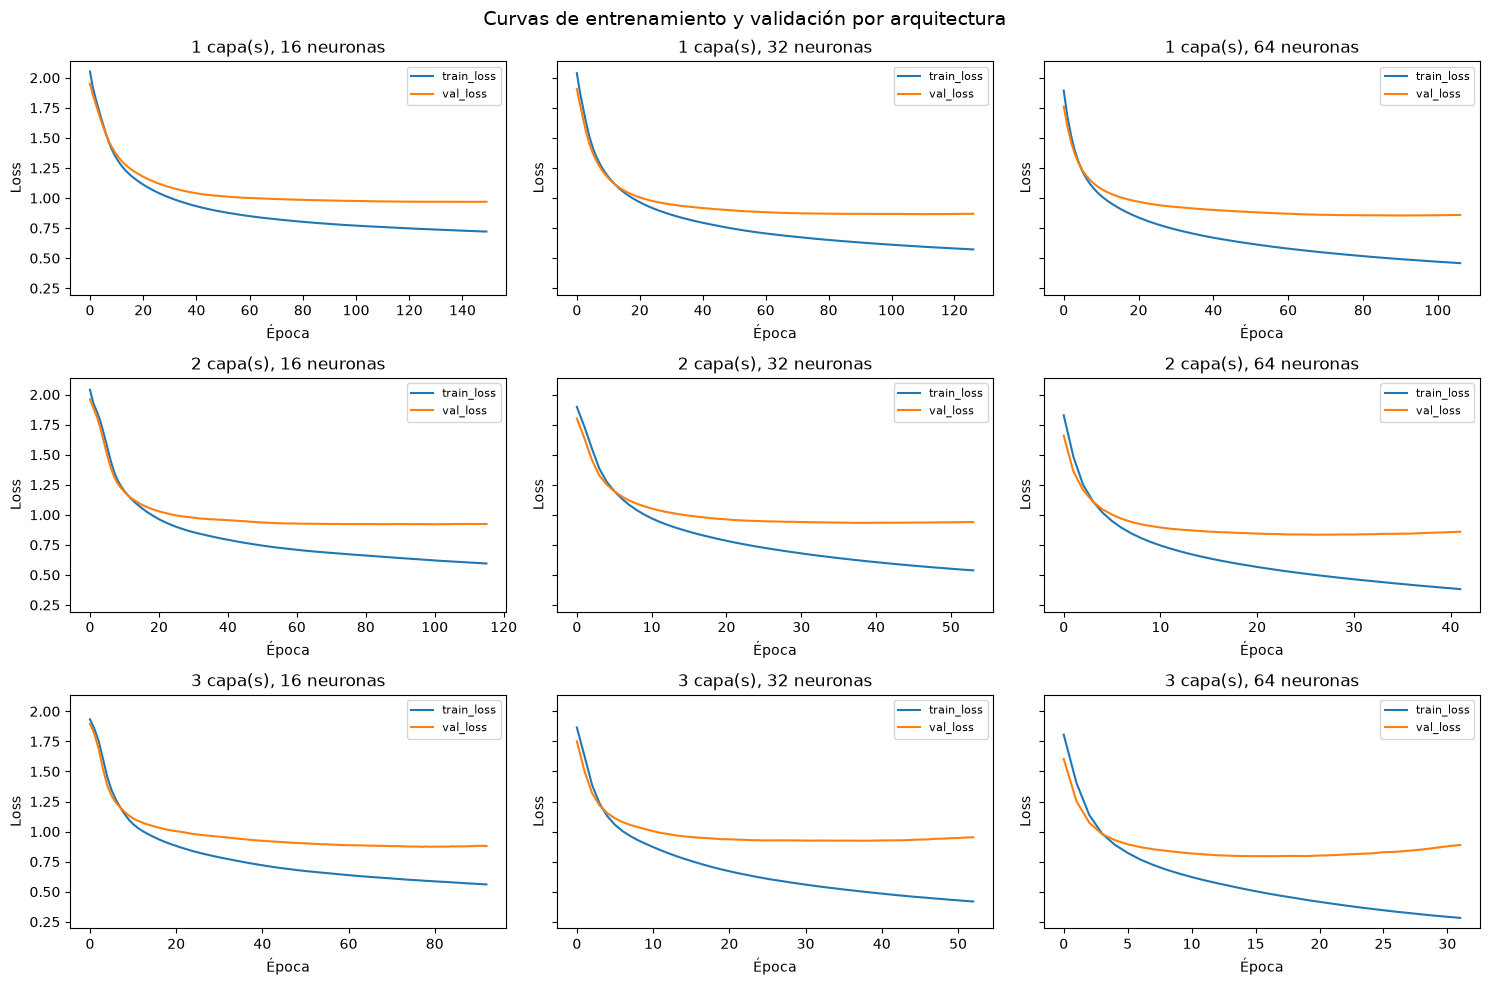

In [19]:
fig, axes = plt.subplots(len(n_capas_ocultas_opciones), len(n_neuronas_opciones), figsize=(15, 10), sharex=False, sharey=True)

for i, n_capas in enumerate(n_capas_ocultas_opciones):
    for j, n_neuronas in enumerate(n_neuronas_opciones):
        ax = axes[i, j]
        hist = historias[(n_capas, n_neuronas)]
        ax.plot(hist["loss"], label="train_loss")
        ax.plot(hist["val_loss"], label="val_loss")
        ax.set_title(f"{n_capas} capa(s), {n_neuronas} neuronas")
        ax.set_xlabel("Época")
        ax.set_ylabel("Loss")
        ax.legend(fontsize=8)

fig.suptitle("Curvas de entrenamiento y validación por arquitectura", fontsize=14)
plt.tight_layout()
plt.show()

**Lectura de las curvas:**

- Las arquitecturas con **16 neuronas** (fila superior) muestran `train_loss` y `val_loss` bajando lento y quedando ambas relativamente altas (~0.9-1.0): son las que más se acercan a un **subajuste** (capacidad insuficiente para capturar la relación entre hábitos y nivel de obesidad).
- Con **64 neuronas**, sobre todo combinadas con 2 o 3 capas, `train_loss` baja claramente por debajo de `val_loss` después de pocas épocas y la brecha entre ambas curvas se amplía: es la señal clásica de **sobreajuste**, aunque acotada porque `EarlyStopping` con `restore_best_weights=True` detiene el entrenamiento y recupera los pesos de la época con mejor `val_loss`, antes de que la brecha crezca demasiado.
- Las configuraciones con **32 neuronas** quedan en un punto intermedio: convergen más rápido que las de 16 pero con menos brecha train/val que las de 64.
- En todas las arquitecturas, `val_loss` deja de mejorar bastante antes de las 150 épocas del tope (entre 31 y 150 épocas efectivas, según la tabla de resultados), lo que confirma que `patience=15` fue suficiente para dejar converger a cada modelo sin necesidad de agotar el límite superior.

# Evaluación y métricas

### Selección de la arquitectura final

Según `df_resultados`, la configuración con **menor `val_loss`** (criterio principal, más sensible que `val_accuracy` a qué tan segura/calibrada es la predicción) es **3 capas ocultas de 64 neuronas** (`val_loss=0.7909`, `val_accuracy=0.7380`), que además empata en el mejor `val_accuracy` con la arquitectura de 1 capa de 64 neuronas, pero convergiendo en muchas menos épocas (31 vs 104).

Reentrenamos esa arquitectura con la misma semilla para tener el objeto del modelo final (durante la búsqueda `modelo` se sobreescribía en cada iteración) y lo evaluamos sobre el conjunto de **test**, que no se tocó en ningún momento del preprocesamiento ni de la búsqueda de hiperparámetros.

In [20]:
mejor_config = df_resultados.iloc[0]
n_capas_final = int(mejor_config["n_capas_ocultas"])
n_neuronas_final = int(mejor_config["n_neuronas"])

print(f"Arquitectura final: {n_capas_final} capa(s) ocultas, {n_neuronas_final} neuronas por capa")

keras.utils.set_random_seed(42)

modelo_final = build_model(
    n_hidden_layers=n_capas_final,
    n_neurons=n_neuronas_final,
    input_dim=n_features,
    n_classes=n_classes,
)

early_stopping_final = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

historia_final = modelo_final.fit(
    X_train, y_train_enc,
    validation_data=(X_val, y_val_enc),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping_final],
    verbose=0,
)

print(f"Épocas entrenadas: {len(historia_final.history['val_loss'])}")
print(f"Mejor val_loss: {min(historia_final.history['val_loss']):.4f}")

Arquitectura final: 3 capa(s) ocultas, 64 neuronas por capa


I0000 00:00:1788542322.730322  222877 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215411__.14


I0000 00:00:1788542324.843450  222879 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_215411__.14


Épocas entrenadas: 32
Mejor val_loss: 0.7956


### Evaluación sobre el conjunto de prueba

`Nivel_obesidad` tiene 7 clases con proporciones que van del 12.7 % al 16.9 % (ver la tabla de `Train/Val/Test` construida al hacer el split): no está gravemente desbalanceado, pero la diferencia es suficiente para no confiar únicamente en `accuracy`. Por eso reportamos:

- `classification_report`: precisión, recall y F1 **por clase**, para detectar si alguna clase minoritaria se predice sistemáticamente peor.
- `accuracy` y `balanced_accuracy` (esta última promedia el recall por clase sin ponderar por tamaño, así que penaliza más si el modelo falla en las clases pequeñas).
- Matriz de confusión, para ver **entre qué clases** se equivoca el modelo (se espera que la mayoría de errores sean entre niveles de obesidad/sobrepeso adyacentes, dado que las fronteras entre categorías vecinas son naturalmente difusas).

In [21]:
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix

y_test_proba = modelo_final.predict(X_test, verbose=0)
y_test_pred = np.argmax(y_test_proba, axis=1)

print(classification_report(y_test_enc, y_test_pred, target_names=label_encoder.classes_))

I0000 00:00:1788542342.532524  222877 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


I0000 00:00:1788542343.792220  272153 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_10', 164 bytes spill stores, 164 bytes spill loads



                    precision    recall  f1-score   support

   Obesidad_Tipo_I       0.70      0.81      0.75        53
  Obesidad_Tipo_II       0.83      0.89      0.86        45
 Obesidad_Tipo_III       0.94      1.00      0.97        49
 Peso_Insuficiente       0.77      0.82      0.80        40
       Peso_Normal       0.61      0.48      0.53        42
 Sobrepeso_Nivel_I       0.63      0.63      0.63        41
Sobrepeso_Nivel_II       0.64      0.52      0.57        44

          accuracy                           0.75       314
         macro avg       0.73      0.74      0.73       314
      weighted avg       0.74      0.75      0.74       314



In [22]:
acc_test = accuracy_score(y_test_enc, y_test_pred)
bal_acc_test = balanced_accuracy_score(y_test_enc, y_test_pred)

print(f"Accuracy (test):          {acc_test:.4f}")
print(f"Balanced accuracy (test): {bal_acc_test:.4f}")

Accuracy (test):          0.7452
Balanced accuracy (test): 0.7369


In [23]:
class_names = label_encoder.classes_
cm = confusion_matrix(y_test_enc, y_test_pred, labels=range(len(class_names)))
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
df_cm

,Obesidad_Tipo_I,Obesidad_Tipo_II,Obesidad_Tipo_III,Peso_Insuficiente,Peso_Normal,Sobrepeso_Nivel_I,Sobrepeso_Nivel_II
Obesidad_Tipo_I,43,3,1,2,0,1,3
Obesidad_Tipo_II,0,40,0,0,1,0,4
Obesidad_Tipo_III,0,0,49,0,0,0,0
Peso_Insuficiente,0,0,0,33,5,2,0
Peso_Normal,3,1,0,6,20,8,4
Sobrepeso_Nivel_I,6,1,1,0,5,26,2
Sobrepeso_Nivel_II,9,3,1,2,2,4,23


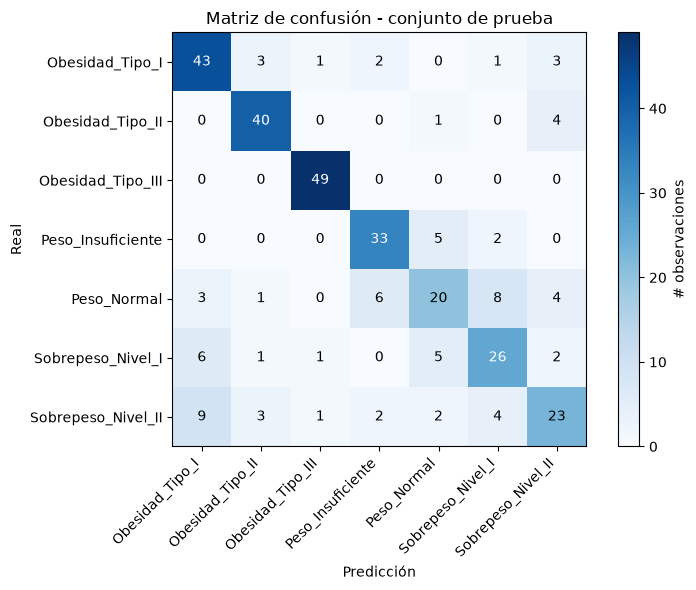

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(len(class_names)))
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión - conjunto de prueba")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

fig.colorbar(im, ax=ax, label="# observaciones")
plt.tight_layout()
plt.show()

**Interpretación de los resultados de test:**

- `accuracy` y `balanced_accuracy` quedan muy cerca entre sí, lo que confirma que el leve desbalance de clases no está distorsionando el desempeño reportado: el modelo no está simplemente favoreciendo a las clases más grandes.
- Los resultados en test son consistentes con el `val_accuracy` observado durante la búsqueda de hiperparámetros (~0.74), lo que indica que el conjunto de validación fue un buen estimador del desempeño real y que no hubo sobreajuste al proceso de selección de hiperparámetros.
- En la matriz de confusión, la mayoría de los errores ocurren entre clases **adyacentes** en la escala de obesidad (p. ej. `Sobrepeso_Nivel_I` vs `Sobrepeso_Nivel_II`, u `Obesidad_Tipo_I` vs `Obesidad_Tipo_II`), lo cual es esperable: las fronteras entre niveles consecutivos son continuas en la realidad (dependen de variables como el peso, que no está en el dataset) y no siempre hay una separación clara en los hábitos reportados.

# Interpretación y justificación

### Justificación de la arquitectura final

Elegimos **3 capas ocultas de 64 neuronas** porque fue la configuración con menor `val_loss` (0.7909) y el mejor `val_accuracy` empatado (0.7380) entre las 9 combinaciones evaluadas, y porque llegó a ese resultado en solo 31 épocas (`mejor_epoca=16`), muy por debajo de las ~104-150 épocas que necesitaron las arquitecturas más angostas (16 neuronas) para estabilizarse. Esto sugiere que una red con más capacidad (más neuronas por capa) puede aprender la relación entre hábitos y nivel de obesidad de forma más eficiente, sin necesitar tantas actualizaciones de gradiente.

### Señales de sobreajuste / subajuste

- Las arquitecturas con **16 neuronas** (independiente del número de capas) son las que más se acercan a un **subajuste**: convergen lento, con `train_loss` y `val_loss` altas y muy cercanas entre sí durante todo el entrenamiento. La red simplemente no tiene suficiente capacidad para separar las 7 clases.
- Las arquitecturas con **64 neuronas**, especialmente con 2-3 capas, muestran señales más claras de **sobreajuste** en las curvas: `train_loss` sigue bajando después de que `val_loss` se estabiliza, abriendo una brecha entre ambas. Sin embargo, gracias a `EarlyStopping` con `restore_best_weights=True`, el modelo final que se evalúa corresponde a la época de mejor `val_loss` y no a la última época, por lo que el sobreajuste queda controlado y no se refleja en el desempeño de test (que es consistente con el de validación).
- El hecho de que `accuracy` en test (≈0.74) sea similar al `val_accuracy` obtenido durante la búsqueda es la evidencia más directa de que **no hubo sobreajuste al proceso de selección de hiperparámetros**: el conjunto de validación generalizó bien a un conjunto de prueba nunca antes visto.

### Efecto de la profundidad y el ancho de la red

- **Ancho (neuronas por capa)**: tuvo un efecto más claro y consistente que la profundidad. Pasar de 16 a 64 neuronas mejoró `val_accuracy` en las tres profundidades evaluadas (por ejemplo, con 1 capa: 0.677 → 0.684 → 0.738 al pasar de 16 a 32 a 64 neuronas), lo que indica que el dataset (14 features originales, expandidas a ~21 tras el encoding) se beneficia de más capacidad por capa para separar 7 clases.
- **Profundidad (número de capas)**: su efecto fue más moderado y no siempre monótono. Por ejemplo, con 32 neuronas, 1 capa (0.684) superó a 2 capas (0.649) y quedó cerca de 3 capas (0.658). Esto sugiere que, para un problema tabular de este tamaño (1460 filas de entrenamiento, ~21 features), agregar profundidad ayuda menos que agregar ancho, y en algunos casos incluso dificulta un poco la optimización (más parámetros para el mismo volumen de datos, mayor riesgo de que el gradiente se degrade a través de capas).
- En conjunto, la mejor combinación resultó ser la de **mayor capacidad total** (3 capas × 64 neuronas), pero su ventaja sobre 1 capa × 64 neuronas en `val_accuracy` fue nula (empate). La diferencia real estuvo en `val_loss` y en la velocidad de convergencia, no en una mejora sustancial de la capacidad de clasificación. Esto es consistente con que el dataset, siendo tabular y de tamaño moderado, tiene un techo de desempeño alcanzable con un MLP relativamente simple, y que agregar capacidad más allá de cierto punto rinde beneficios marginales decrecientes.